# Brain-surface figures for the IS-RSA / group results

Renders any saved result (`mean_r` over 116 ROIs + `sig_rois`) as raw and thresholded cortical surface
maps. This is Jin's `step04` plotting (nilearn + Schaefer-100 + Tian-16) — equivalent to Hayoung's
`visualize_brain_raw` / `visualize_brain_thres`. Set `TEMPLATE_DIR` to Jin's `template/` folder (from Box/repo).

In [1]:
import os, numpy as np
from nilearn.image import load_img, new_img_like
from nilearn import datasets, surface
from nilearn.plotting import plot_surf_stat_map
import matplotlib.pyplot as plt, seaborn as sns

# --- set these ---
from config import TEMPLATE_DIR
import sys; sys.path.insert(0, "jin_code")
# = Jin step08 volume/surface builders, imported VERBATIM (jin_step08.py, his code).
from jin_step08 import build_nifti_mask, build_brain_volume, plot_surface_map
RESULT_NPY   = "results/IS-RSA/04a__jin_impressions_isrsa_after.npy"   # any saved result with mean_r + sig_rois
SIG_KEY      = "sig_rois_figure"   # or "sig_rois" for the posted-method regions
nroi_cor, nroi_sub = 100, 16

In [2]:
# = Jin step08 build_nifti_mask / build_brain_volume (imported above, his verbatim code).
#   His build_nifti_mask(nroi_cor, nroi_sub, directory) expects the PARENT of the 'template' dir;
#   our TEMPLATE_DIR *is* that template dir, so we pass its parent.
#   build_brain_volume is his vectorized ROI->voxel mapping -- verified identical to the earlier
#   triple-loop version (max|diff|=0.00e+00 on all colored voxels; his unthresholded bg=0, threshold bg=NaN).
REF = os.path.join(TEMPLATE_DIR, "tpl-MNI152NLin2009cAsym",
                   "tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-100Parcels17Networks_dseg.nii.gz")
mask = build_nifti_mask(nroi_cor, nroi_sub, os.path.dirname(TEMPLATE_DIR))     # = Jin's atlas mask
def make_brain_map(vals, sig=None):                                            # thin wrapper over his build_brain_volume
    return new_img_like(load_img(REF), build_brain_volume(mask, vals, sig_rois=sig))

plotting results/IS-RSA/04a__jin_impressions_isrsa_after.npy | sig ROIs: [2, 5, 9, 27, 28, 60, 64, 70, 93, 94, 97, 98, 112]


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

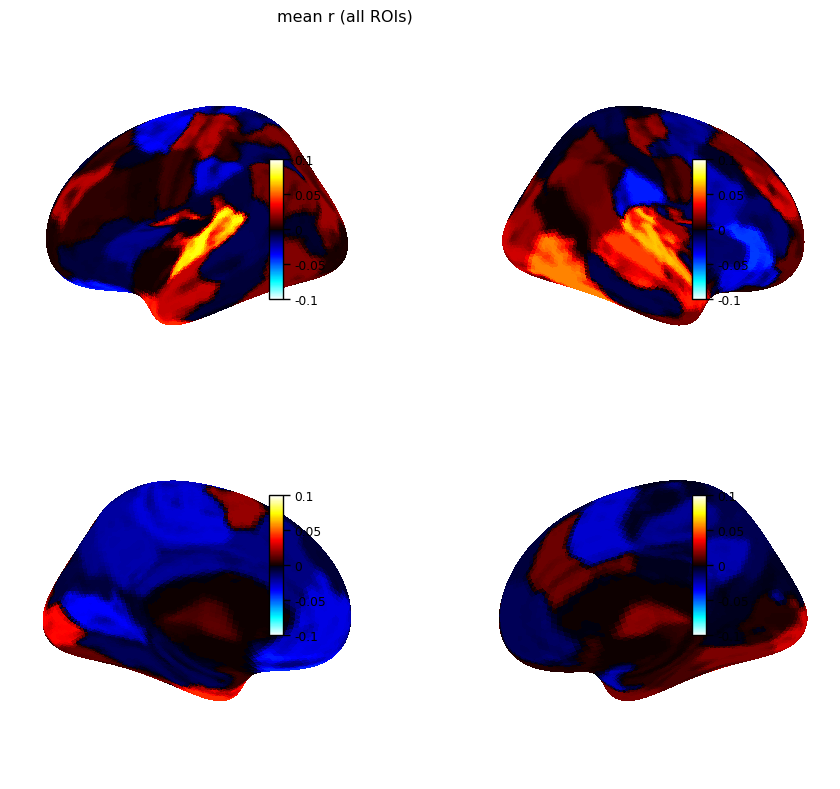

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

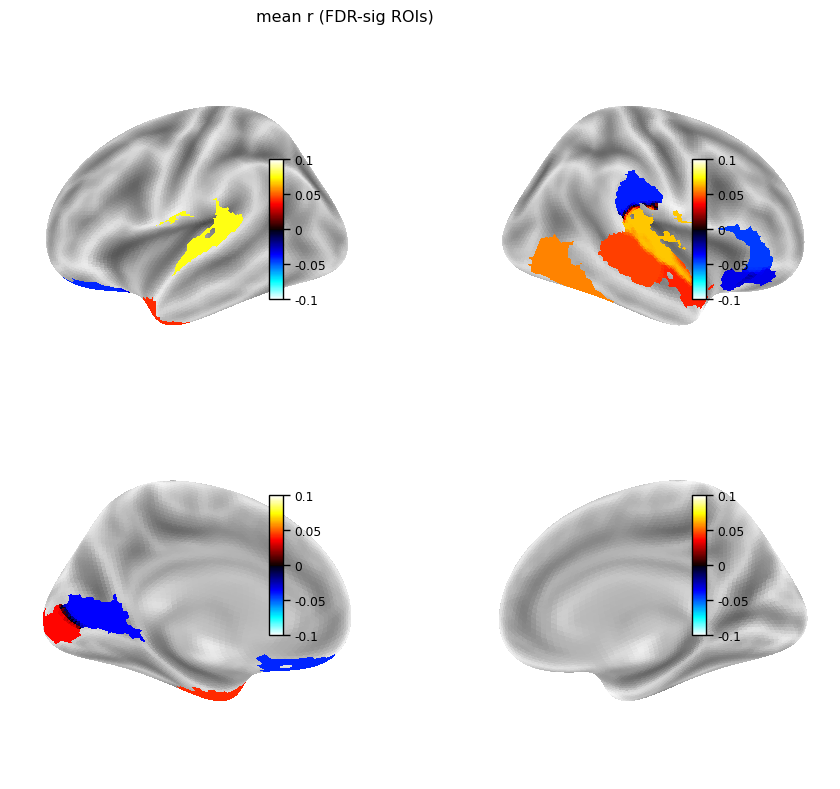

In [3]:
# NOTE: surf_plot below == Jin step08 draw_surface_views (same plot_surf_stat_map lateral+medial x L/R).
# The fully-Jin one-call path is his plot_surface_map(mean_r, mask, load_img(REF), fs,
#   sig_rois=sig, vmin=-0.10, vmax=0.10, save_path=...) -- we keep surf_plot only for INLINE display
#   (his version does plt.close()), and use vmin/vmax=+/-0.10 (not his default +/-0.30) so the small
#   IS-RSA effects (~0.05) are visible. Volume construction is his build_brain_volume (via make_brain_map).
d=np.load(RESULT_NPY, allow_pickle=True).item()
mean_r=np.asarray(d["mean_r"],float); sig=[int(x) for x in d.get(SIG_KEY, d.get("sig_rois",[]))]
print("plotting", RESULT_NPY, "| sig ROIs:", sig)
fs=datasets.fetch_surf_fsaverage(mesh="fsaverage5")
def surf_plot(img, title, out):
    sl=surface.vol_to_surf(img,fs.pial_left); sr=surface.vol_to_surf(img,fs.pial_right)
    sns.set_context("paper"); fig,((a,b),(c,e))=plt.subplots(2,2,subplot_kw={"projection":"3d"},figsize=(10,8))
    kw=dict(cmap="cold_hot",vmin=-0.10,vmax=0.10,colorbar=True)
    plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
    plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
    plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="medial",bg_map=fs.sulc_left,axes=c,**kw)
    plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="medial",bg_map=fs.sulc_right,axes=e,**kw)
    fig.suptitle(title); os.makedirs("results/figures",exist_ok=True)
    plt.tight_layout(); plt.savefig(out,dpi=300,bbox_inches="tight"); plt.show()
surf_plot(make_brain_map(mean_r), "mean r (all ROIs)", "results/figures/08__brain_raw.png")
if sig: surf_plot(make_brain_map(mean_r, sig), "mean r (FDR-sig ROIs)", "results/figures/08__brain_thresholded.png")

## Named ROIs — region labels for every result

`roi_labels.py` maps each 0–115 ROI index to its Schaefer-100 (17-network) / Tian-S1 name. Use `name_rois([...])`
to label any ROI list, and the table below (`results/results_summary_named.csv`) for the full named results.
Surface maps added here should pass ROI indices through `ROI_NAME` for titles/legends.

In [4]:
import pandas as pd
from roi_labels import name_rois, ROI_NAME   # name_rois([24,48,60]) -> [(24,'LH Salience/VentAttn (FrMed_1)'), ...]

# full named results table
summary = pd.read_csv('results/results_summary_named.csv')
pd.set_option('display.max_colwidth', 120)
print(summary.to_string(index=False))

# example: name your primary `like` regions
print('\nlike IS-RSA regions:', name_rois([24,48,60]))
print('group like region:  ', name_rois([91]))

                                                    analysis                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## Surface maps for ALL results (one pass)

Loops every key result through the existing `make_brain_map` / `surf_plot` (run cells 1–3 first so `mask`, `make_brain_map`, `fs`, and `surf_plot` are defined). Each result gets an all-ROIs map and, if it has FDR-significant regions, a thresholded map titled with the Schaefer/Tian region names. Saves to `results/figures/08__<name>_{raw,sig}.png`.

jin_impressions        sig=[2, 5, 9, 27, 28, 60, 64, 70, 93, 94, 97, 98, 112]  -> LH Visual (ExStr_3); LH Visual (ExStrInf_2); LH Somatomotor (Aud_1); LH Limbic (OFC_1); LH Limbic (TempPole_1); RH Somatomotor (S2_1); RH DorsalAttn (SPL_1); RH Salience/VentAttn (ParOper_1); RH DMN (PFCv_1); RH DMN (PFCv_2); RH Temporoparietal (1); RH Temporoparietal (2); LH NucleusAccumbens


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

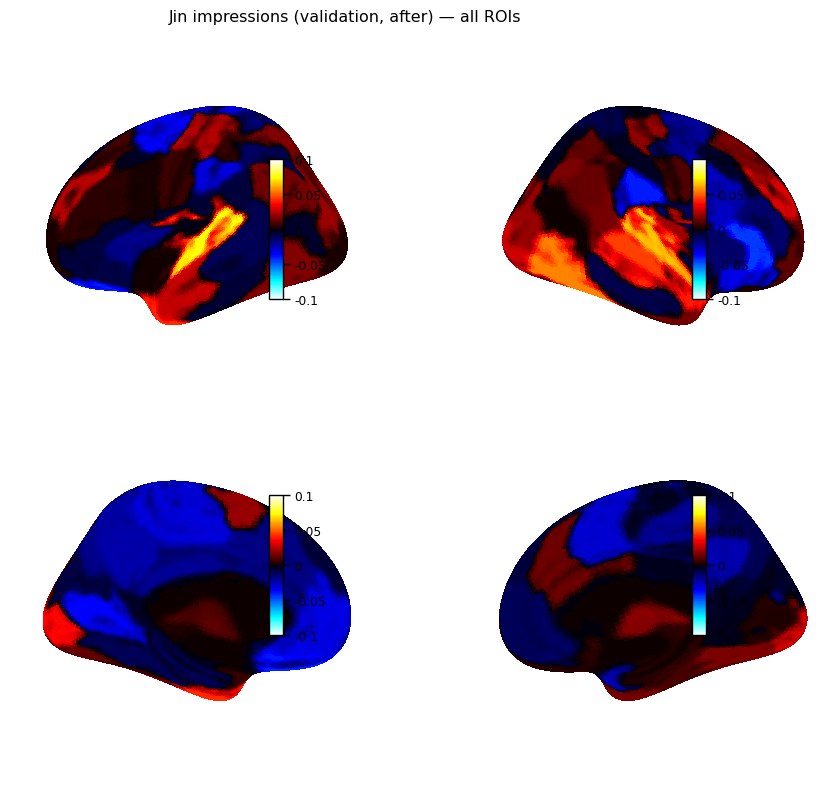

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

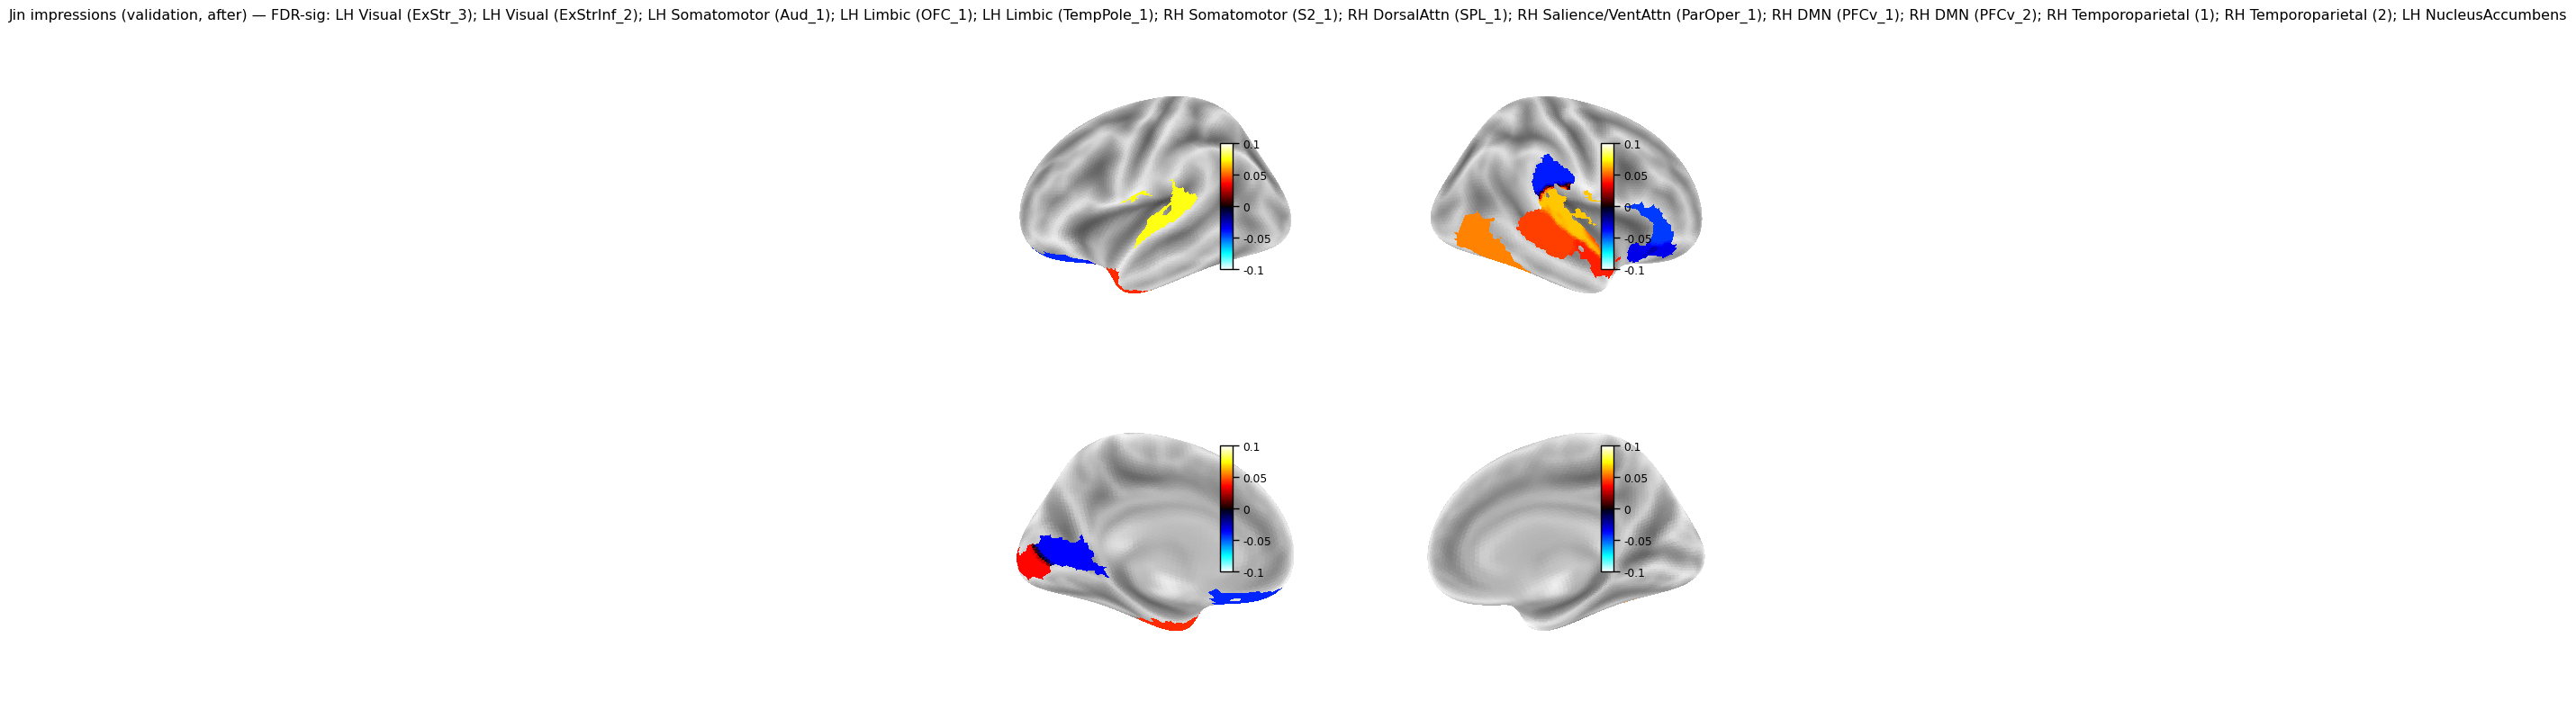

like                   sig=[24, 48, 60]  -> LH Salience/VentAttn (FrMed_1); LH DMN (PHC_1); RH Somatomotor (S2_1)


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

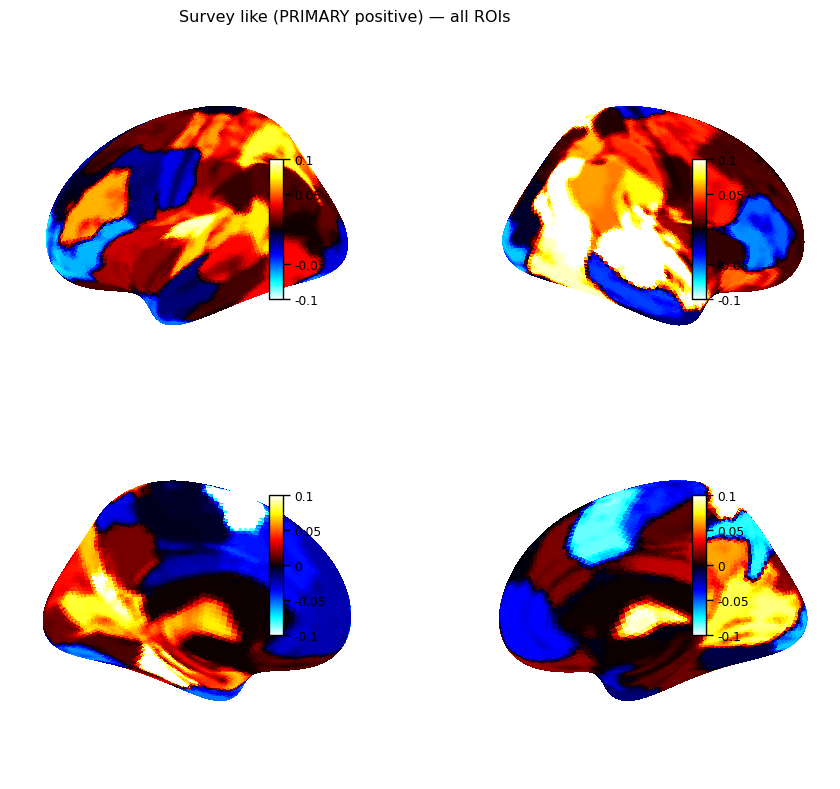

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

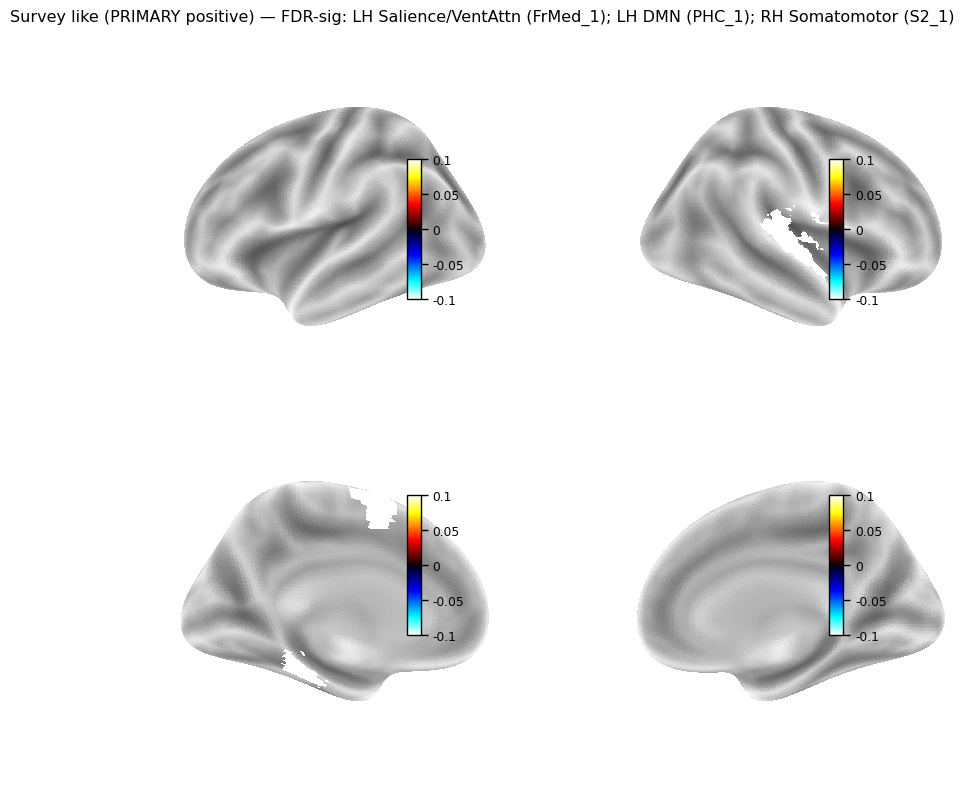

posvalence             sig=[65]  -> RH DorsalAttn (SPL_2)


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

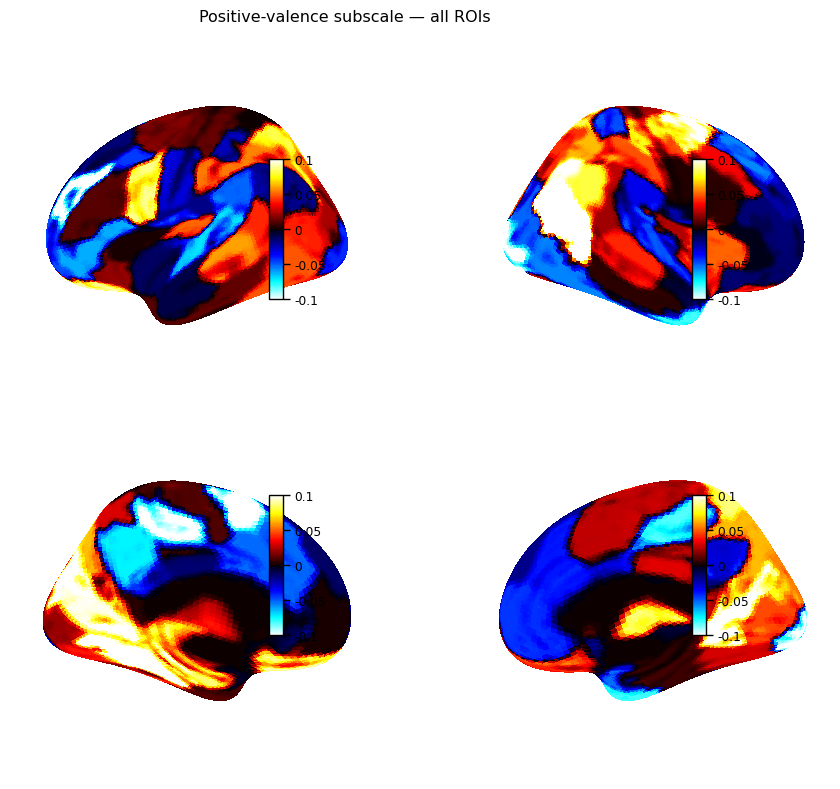

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/plotting/_utils.py:133: RuntimeWarning: All-NaN slice encountered
  data_min = np.nanmin(data)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/plotting/_utils.py:136: RuntimeWarning: All-NaN slice encountered
  data_max = np.nanmax(data)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in

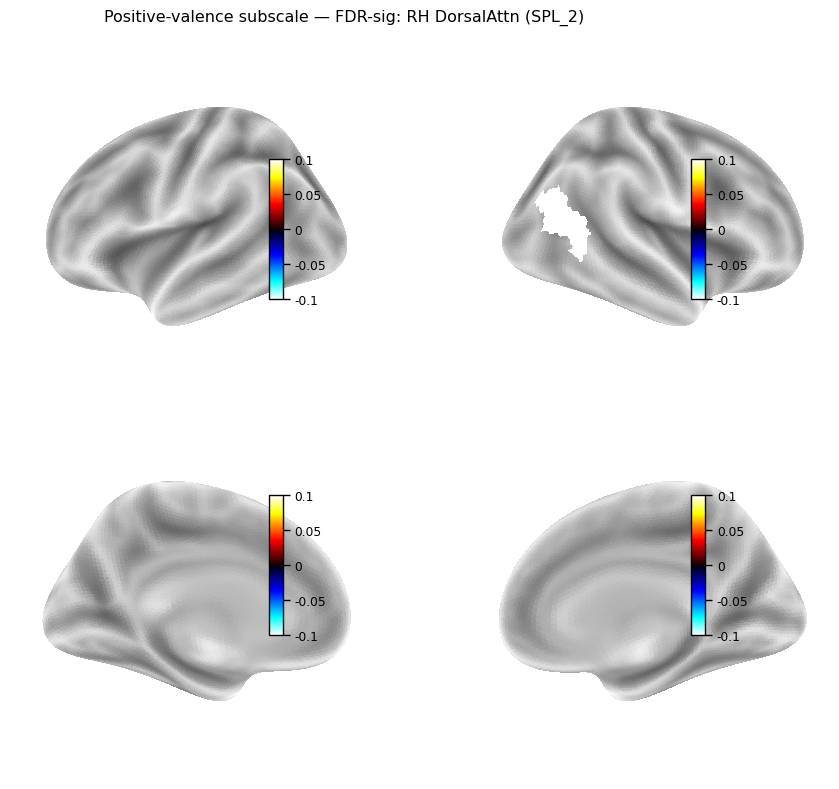

PC1                    sig=[70]  -> RH Salience/VentAttn (ParOper_1)


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

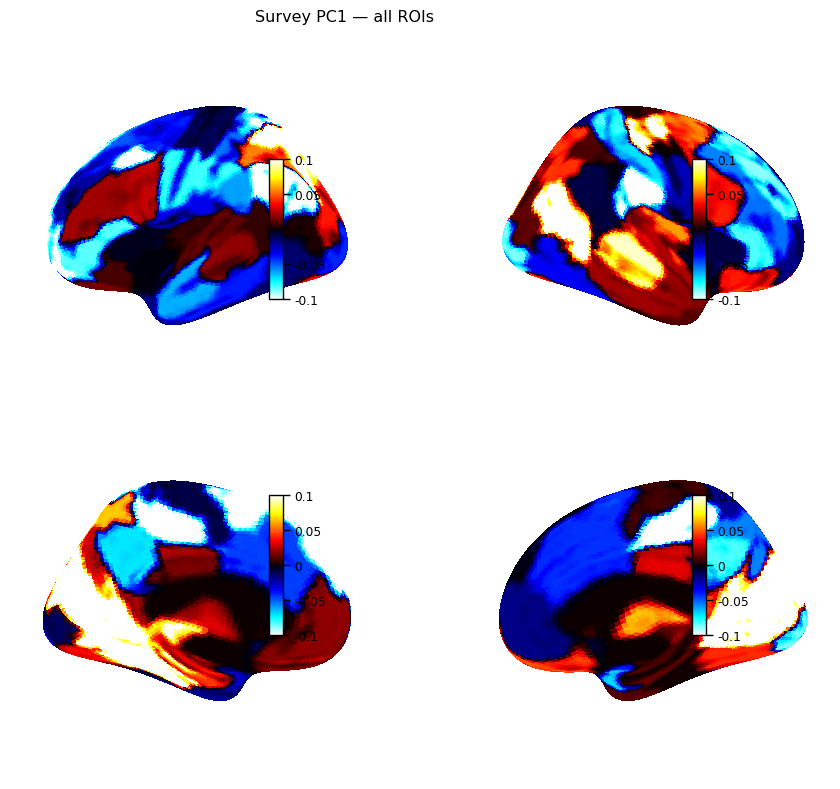

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/plotting/_utils.py:133: RuntimeWarning: All-NaN slice encountered
  data_min = np.nanmin(data)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/plotting/_utils.py:136: RuntimeWarning: All-NaN slice encountered
  data_max = np.nanmax(data)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in

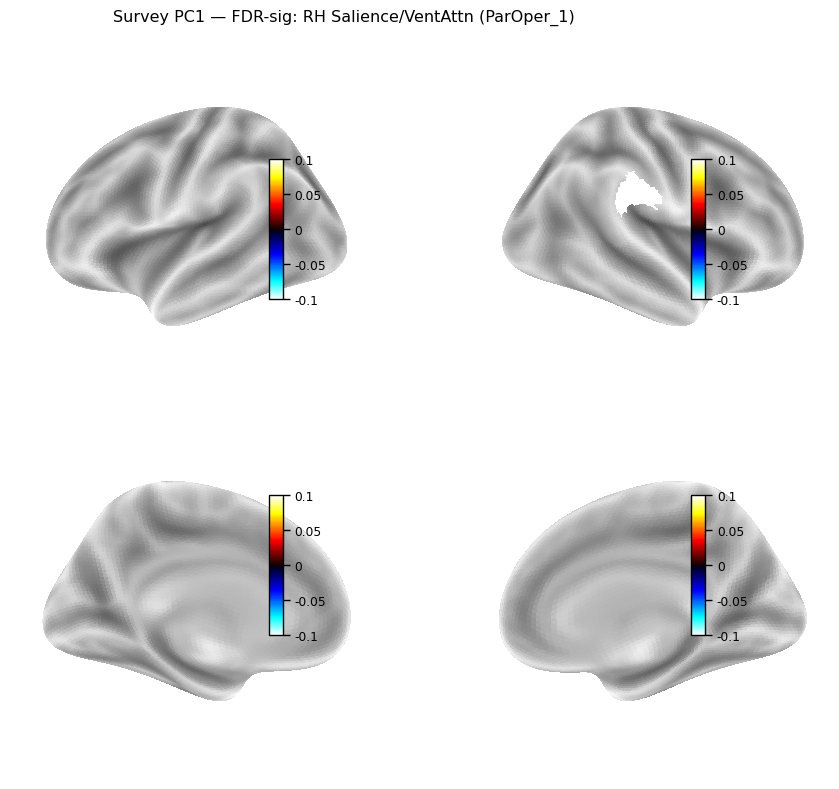

positive_emotion       sig=[]  -> none


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

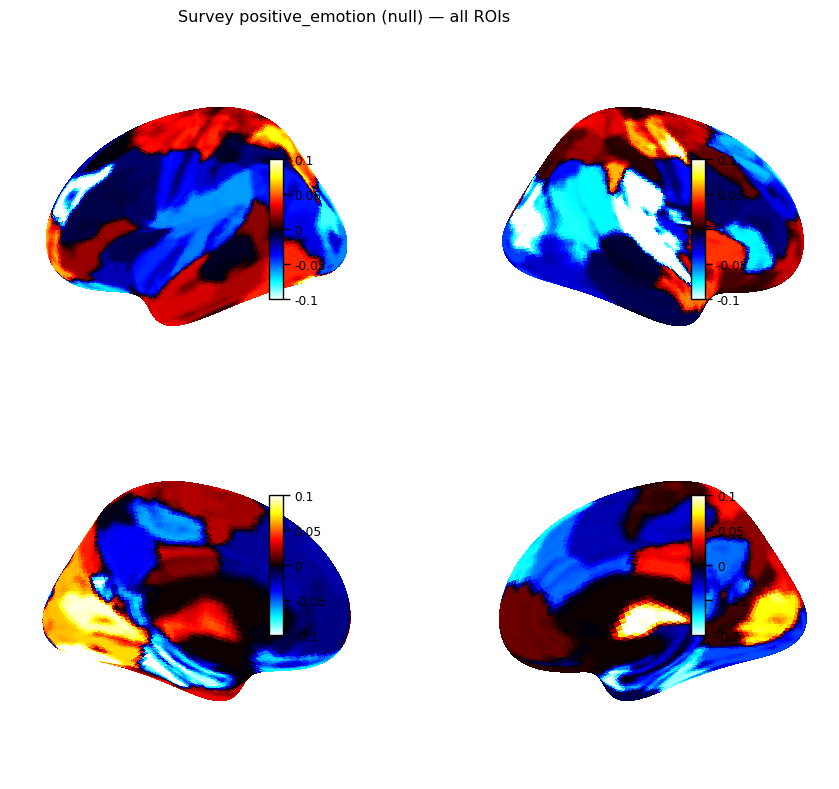

sentiment3d            sig=[]  -> none


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

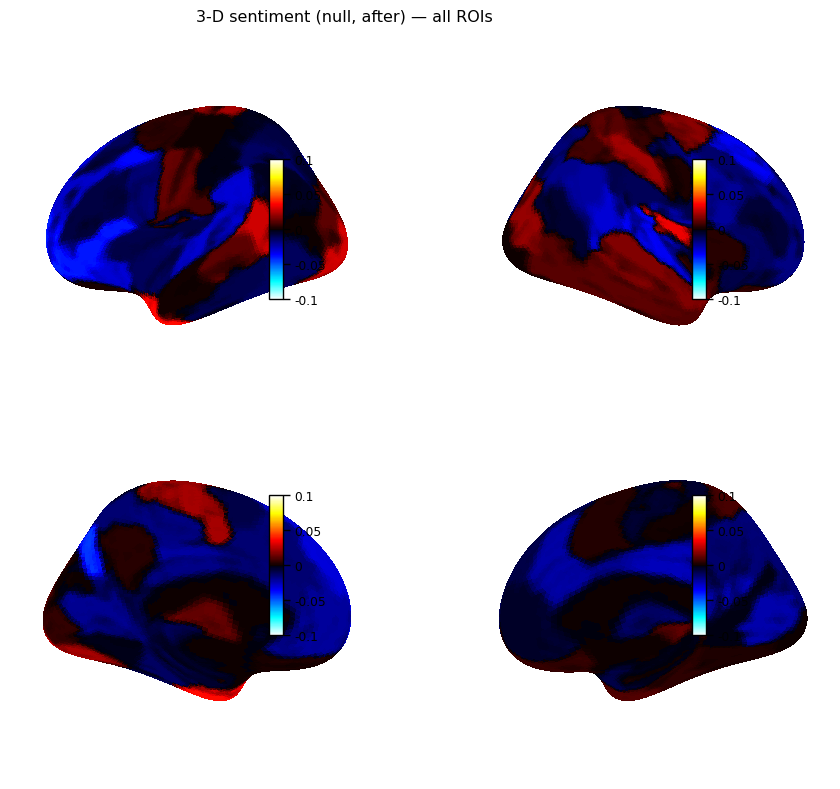

embedding              sig=[9, 60]  -> LH Somatomotor (Aud_1); RH Somatomotor (S2_1)


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

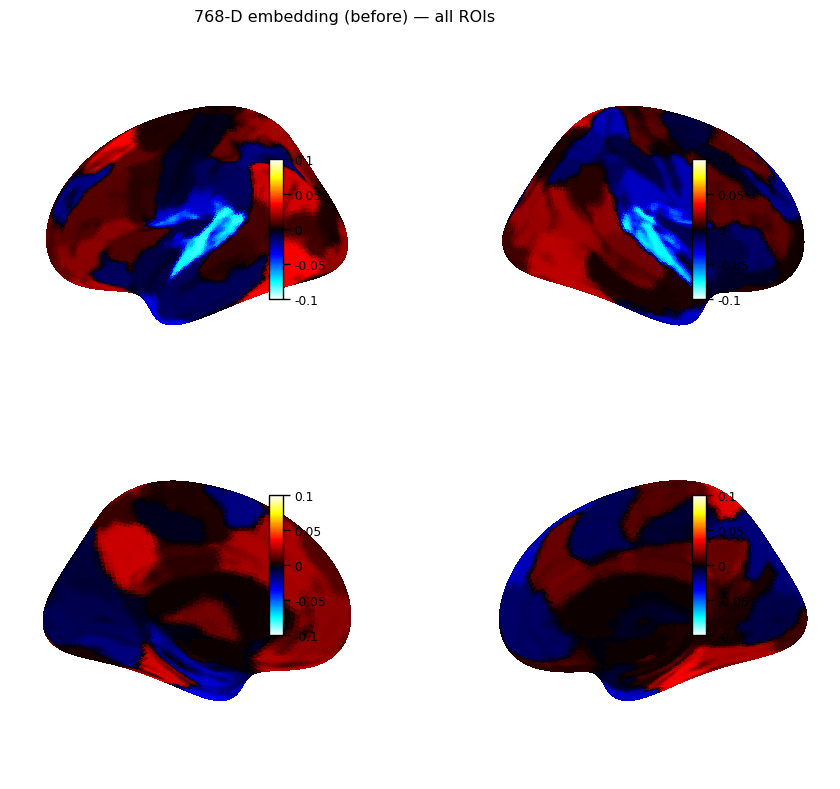

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

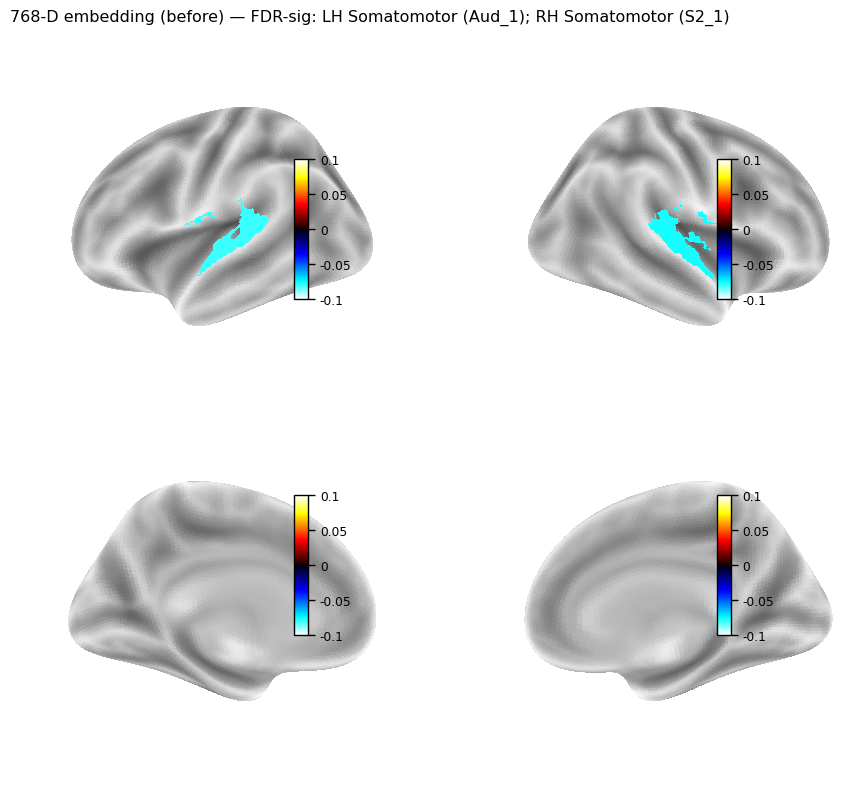

sentiment12d           sig=[0, 1, 97, 115]  -> LH Visual (ExStr_1); LH Visual (ExStr_2); RH Temporoparietal (1); LH Caudate


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

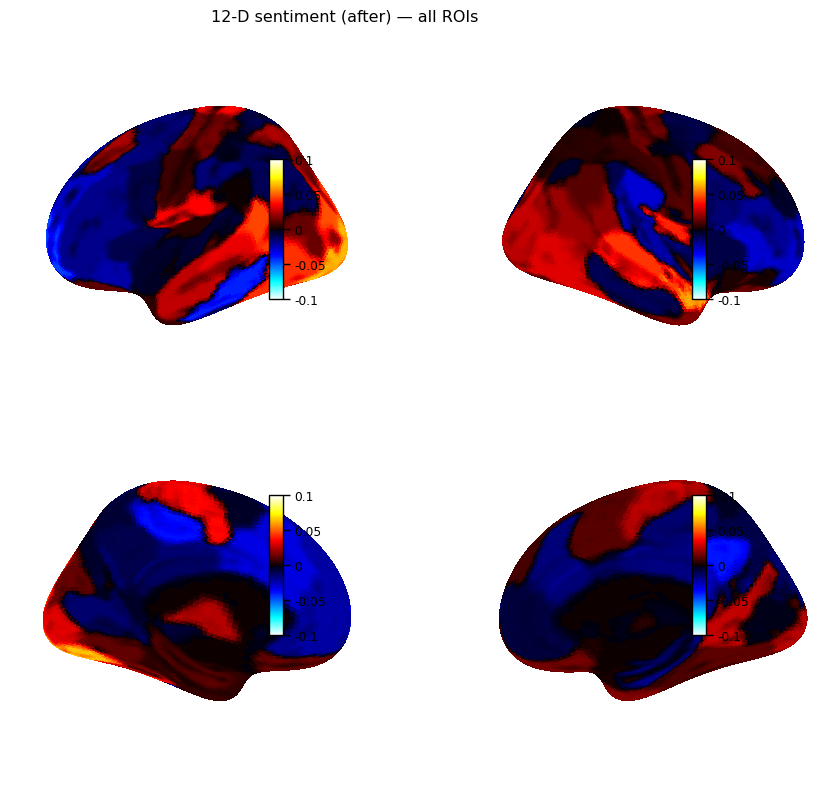

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

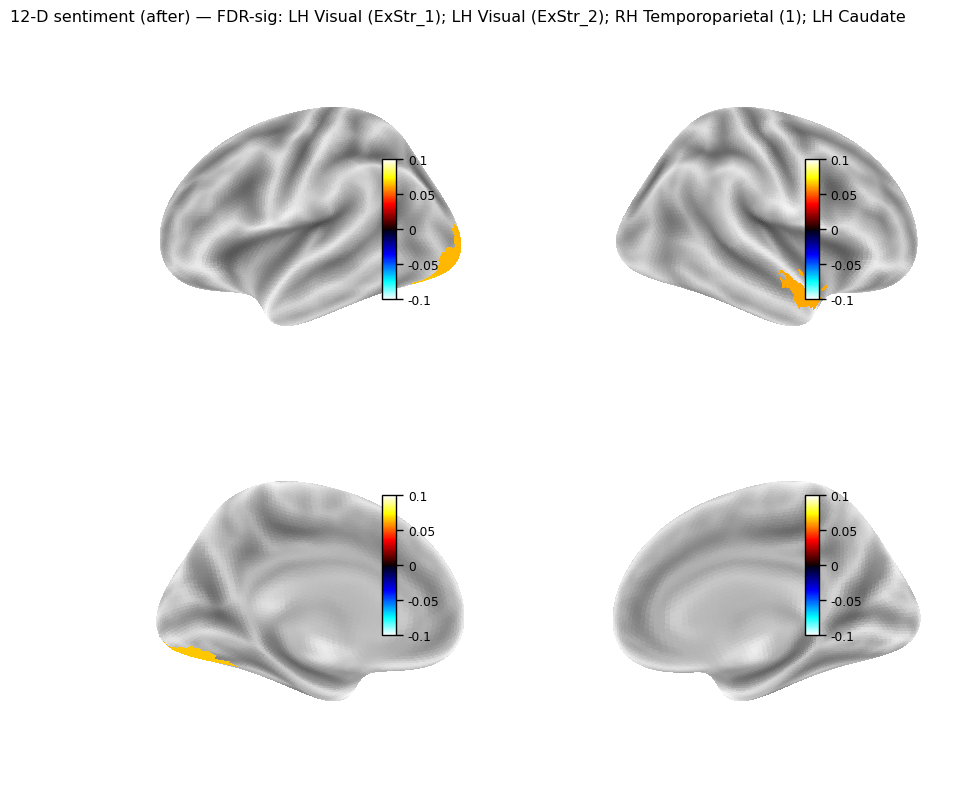

group_like             sig=[91]  -> RH DMN (PFCm_1)


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

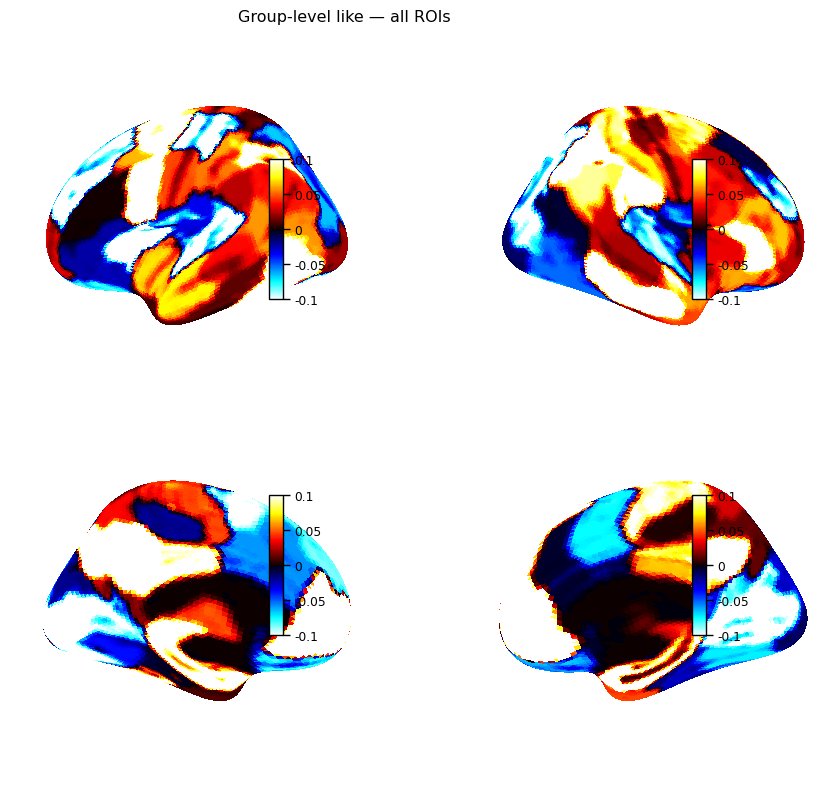

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

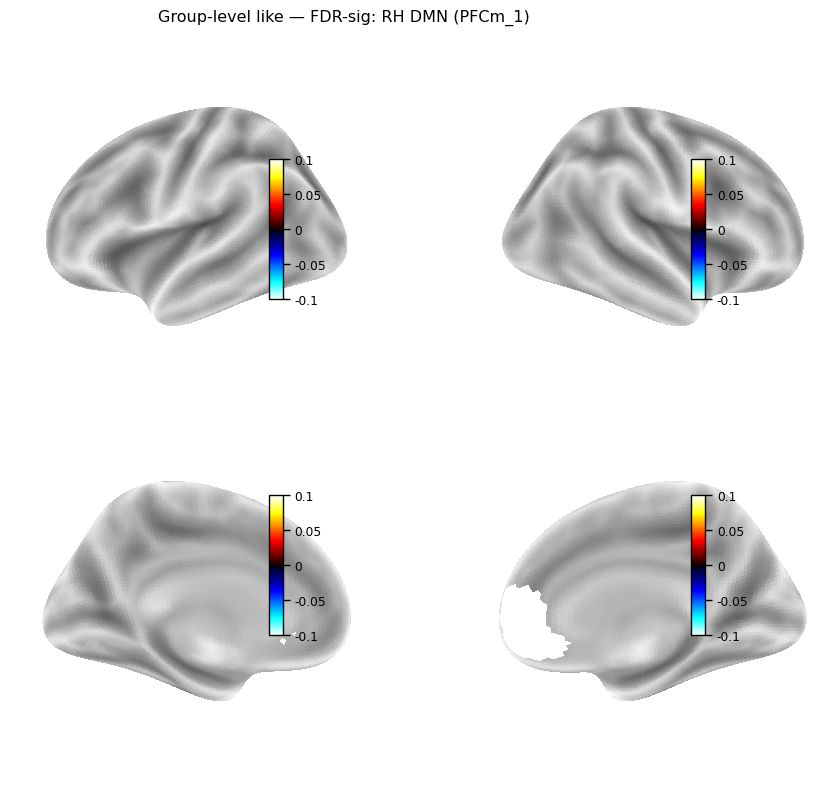

group_char_valence     sig=[101]  -> RH Amygdala


/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="lateral",bg_map=fs.sulc_left,axes=a,**kw)
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:15: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_right,sr,hemi="right",view="lateral",bg_map=fs.sulc_right,axes=b,**kw)
/var/folders/lk/3

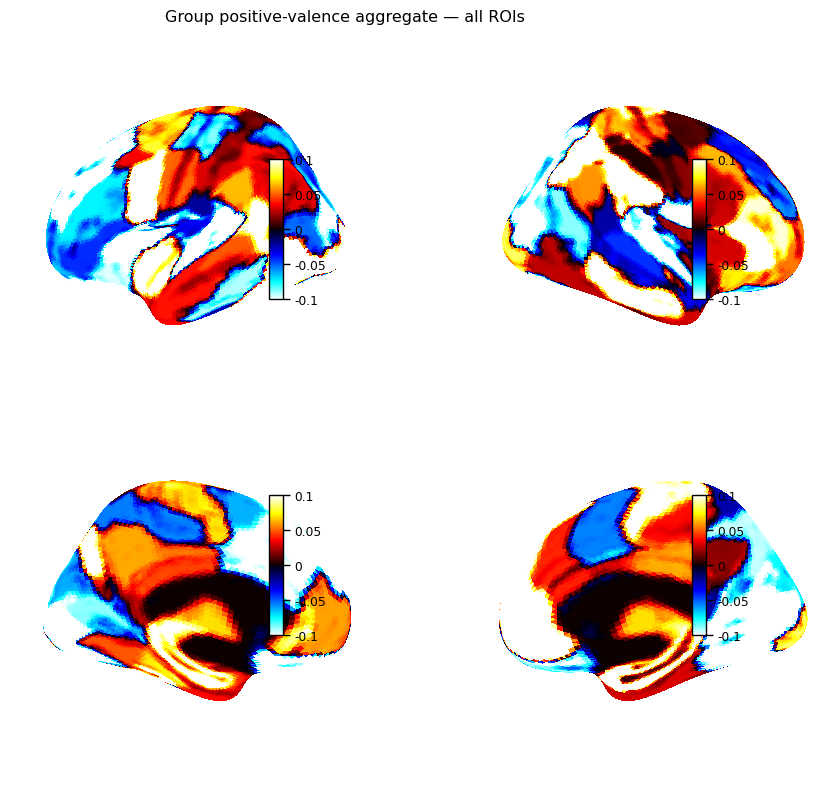

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/plotting/_utils.py:133: RuntimeWarning: All-NaN slice encountered
  data_min = np.nanmin(data)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/plotting/_utils.py:136: RuntimeWarning: All-NaN slice encountered
  data_max = np.nanmax(data)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in

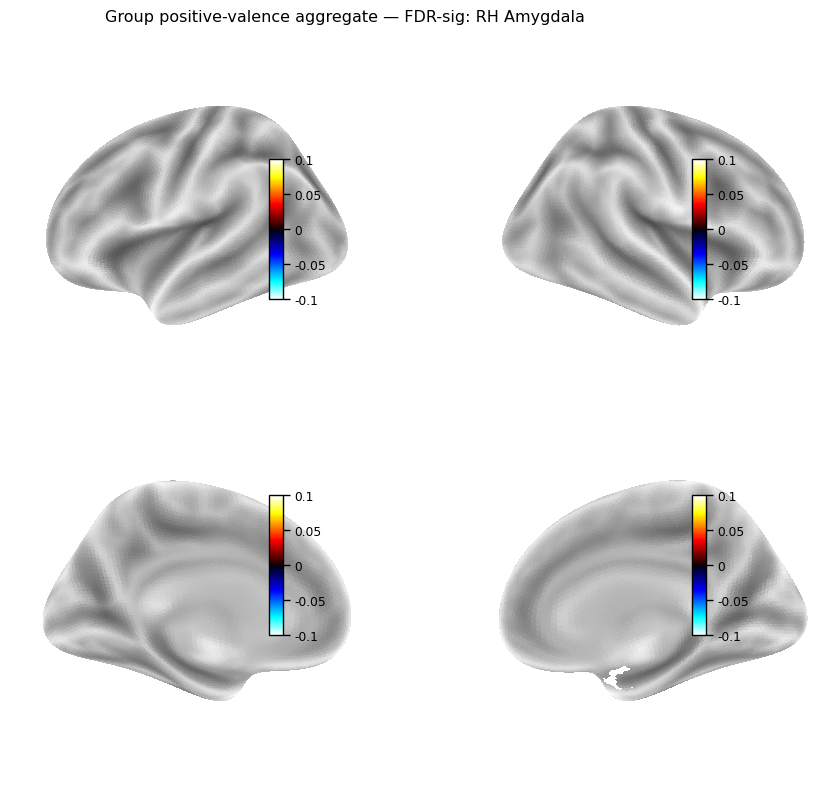


Done -> results/figures/08__<name>_{raw,sig}.png

localizer TR-2: 61 ROIs


/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Library/Python/3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8899/3896773507.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plot_surf_stat_map(fs.infl_left,sl,hemi="left",view="late

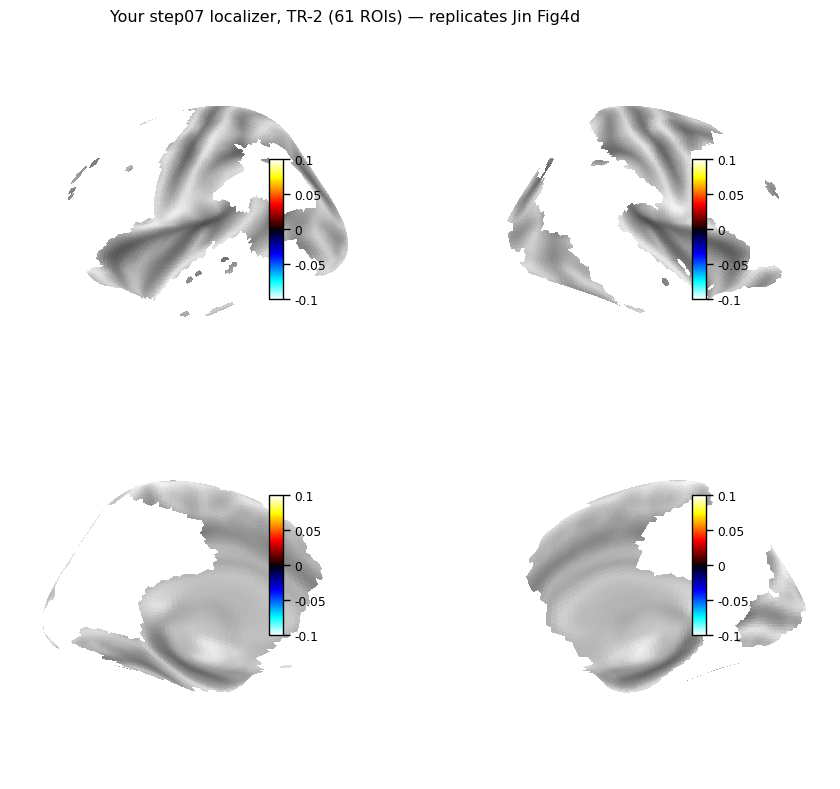

In [5]:
# 08.2 · Render surface maps for every key result (reuses make_brain_map / surf_plot / fs from cells 1-3).
from roi_labels import name_rois

PLOTS = [
 # (result file, sig-key, short-name, title)
 ("results/IS-RSA/04a__jin_impressions_isrsa_after.npy",       "sig_rois_figure", "jin_impressions",  "Jin impressions (validation, after)"),
 ("results/IS-RSA/04c__survey_like_nonPCA_isrsa.npy",          "sig_rois",        "like",             "Survey like (PRIMARY positive)"),
 ("results/IS-RSA/04c__survey_posvalence_isrsa.npy",           "sig_rois",        "posvalence",       "Positive-valence subscale"),
 ("results/IS-RSA/04c__survey_PC1_PCA_isrsa.npy",              "sig_rois",        "PC1",              "Survey PC1"),
 ("results/IS-RSA/04c__survey_positive_emotion_nonPCA_isrsa.npy","sig_rois",      "positive_emotion", "Survey positive_emotion (null)"),
 ("results/IS-RSA/04b__sentiment_isrsa_after.npy",             "sig_rois",        "sentiment3d",      "3-D sentiment (null, after)"),
 ("results/IS-RSA/04b.1__sentiment_isrsa_before.npy",          "sig_rois",        "embedding",        "768-D embedding (before)"),
 ("results/IS-RSA/04b__sentiment12d_isrsa_after.npy",          "sig_rois",        "sentiment12d",     "12-D sentiment (after)"),
 ("results/step5/05__group_brain_like.npy",                    "sig_rois",        "group_like",       "Group-level like"),
 ("results/step5/05__group_brain_char_valence_composite.npy",  "sig_rois",        "group_char_valence","Group positive-valence aggregate"),
]
for path, sigkey, name, title in PLOTS:
    if not os.path.exists(path):
        print("skip (missing):", path); continue
    d   = np.load(path, allow_pickle=True).item()
    val = np.asarray(d.get("mean_r", d.get("r")), float)        # IS-RSA uses mean_r; 05 group uses r
    sig = [int(x) for x in d.get(sigkey, d.get("sig_rois", []))]
    named = "; ".join(n for _, n in name_rois(sig)) if sig else "none"
    print(f"{name:22s} sig={sig}  -> {named}")
    surf_plot(make_brain_map(val),      f"{title} — all ROIs",              f"results/figures/08__{name}_raw.png")
    if sig:
        surf_plot(make_brain_map(val, sig), f"{title} — FDR-sig: {named}",  f"results/figures/08__{name}_sig.png")
print("\nDone -> results/figures/08__<name>_{raw,sig}.png")

# --- your own step07 localizer (magnitude map, peak TR = -2) -- own colour scale ---
own = np.load("results/step6/06__own_step07_hrf4.npy", allow_pickle=True).item()
actual = np.asarray(own["actual"], float)            # (116, 9); TR index 3 == TR -2 (peak)
sig07  = [int(x) for x in own["sig_step07"][3]]
print(f"\nlocalizer TR-2: {len(sig07)} ROIs")
surf_plot(make_brain_map(actual[:,3], sig07),
          f"Your step07 localizer, TR-2 ({len(sig07)} ROIs) — replicates Jin Fig4d",
          "results/figures/08__own_step07_TR-2.png")